# ScholarRAG — Evaluation Dashboard

Comprehensive visualizations of retrieval quality, faithfulness, MSA confidence calibration, ablation studies, and inter-annotator agreement.

In [1]:
import json, csv, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter

sns.set_theme(style="whitegrid", font_scale=1.15)
PAL = ["#FF6F00", "#FFA000", "#FFD54F", "#4FC3F7", "#0288D1", "#01579B", "#E65100"]
sns.set_palette(PAL)

DATA = pathlib.Path("data")

retrieval = json.loads((DATA / "retrieval/retrieval_eval_120q_crossdoc.json").read_text())
claims    = json.loads((DATA / "llm_judge/judge_claims_extracted.json").read_text())
calib     = json.loads((DATA / "calibration/calibration_eval_final_report.json").read_text())
iaa       = json.loads((DATA / "iaa/iaa_report.json").read_text())
judge_raw = json.loads((DATA / "llm_judge/judge_eval_final.json").read_text())

human_csv = DATA / "human_labels/claim_scores_scored.csv"
human_rows = []
with open(human_csv) as f:
    for row in csv.DictReader(f):
        if row.get("support_label") and row.get("msa_M"):
            try:
                human_rows.append({
                    "M": float(row["msa_M"]),
                    "S": float(row.get("msa_S", 0.5)),
                    "A": float(row.get("msa_A", 0.5)),
                    "label": row["support_label"].strip().lower()
                })
            except: pass
df_human = pd.DataFrame(human_rows)

print(f"Loaded: {len(claims)} LLM claims, {len(df_human)} human claims, {retrieval['case_count']} retrieval queries")

Loaded: 638 LLM claims, 634 human claims, 120 retrieval queries


---
## 1. Retrieval Evaluation (120 Cross-Document Queries)

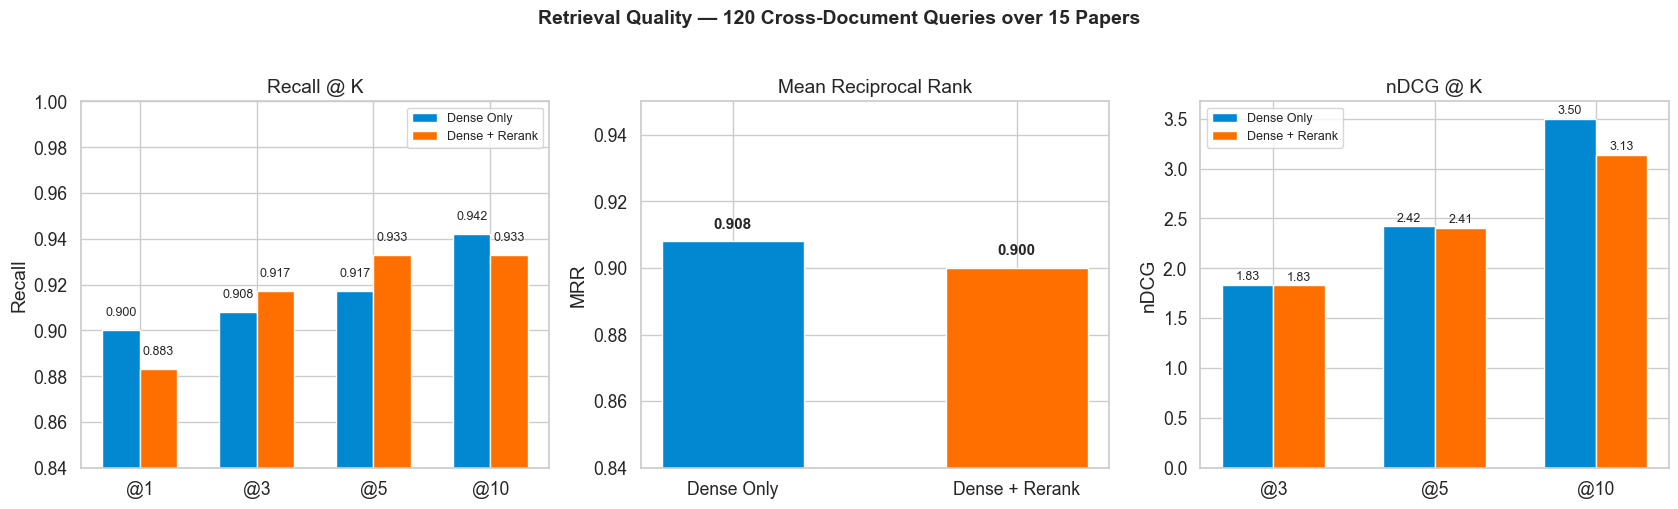

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# --- Recall@K ---
ks = ["1", "3", "5", "10"]
recall_only   = [retrieval["metrics_retrieval_only"]["recall_at"][k] for k in ks]
recall_rerank = [retrieval["metrics_retrieval_rerank"]["recall_at"][k] for k in ks]
x = np.arange(len(ks)); w = 0.32
axes[0].bar(x - w/2, recall_only,   w, label="Dense Only",    color=PAL[4], edgecolor="white")
axes[0].bar(x + w/2, recall_rerank, w, label="Dense + Rerank", color=PAL[0], edgecolor="white")
for i, (a, b) in enumerate(zip(recall_only, recall_rerank)):
    axes[0].text(i - w/2, a + 0.005, f"{a:.3f}", ha="center", va="bottom", fontsize=9)
    axes[0].text(i + w/2, b + 0.005, f"{b:.3f}", ha="center", va="bottom", fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels([f"@{k}" for k in ks])
axes[0].set_ylim(0.84, 1.0); axes[0].set_ylabel("Recall")
axes[0].set_title("Recall @ K"); axes[0].legend(fontsize=9)

# --- MRR ---
mrr_vals = [retrieval["metrics_retrieval_only"]["mrr"],
            retrieval["metrics_retrieval_rerank"]["mrr"]]
bars = axes[1].bar(["Dense Only", "Dense + Rerank"], mrr_vals, color=[PAL[4], PAL[0]], edgecolor="white", width=0.5)
for b in bars:
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
                 f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[1].set_ylim(0.84, 0.95); axes[1].set_ylabel("MRR")
axes[1].set_title("Mean Reciprocal Rank")

# --- nDCG@K ---
ndcg_ks = ["3", "5", "10"]
ndcg_only   = [retrieval["metrics_retrieval_only"]["ndcg_at"][k] for k in ndcg_ks]
ndcg_rerank = [retrieval["metrics_retrieval_rerank"]["ndcg_at"][k] for k in ndcg_ks]
x2 = np.arange(len(ndcg_ks))
axes[2].bar(x2 - w/2, ndcg_only,   w, label="Dense Only",    color=PAL[4], edgecolor="white")
axes[2].bar(x2 + w/2, ndcg_rerank, w, label="Dense + Rerank", color=PAL[0], edgecolor="white")
for i, (a, b) in enumerate(zip(ndcg_only, ndcg_rerank)):
    axes[2].text(i - w/2, a + 0.02, f"{a:.2f}", ha="center", va="bottom", fontsize=9)
    axes[2].text(i + w/2, b + 0.02, f"{b:.2f}", ha="center", va="bottom", fontsize=9)
axes[2].set_xticks(x2); axes[2].set_xticklabels([f"@{k}" for k in ndcg_ks])
axes[2].set_ylabel("nDCG"); axes[2].set_title("nDCG @ K"); axes[2].legend(fontsize=9)

fig.suptitle("Retrieval Quality — 120 Cross-Document Queries over 15 Papers", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_retrieval.png", dpi=180, bbox_inches="tight")
plt.show()

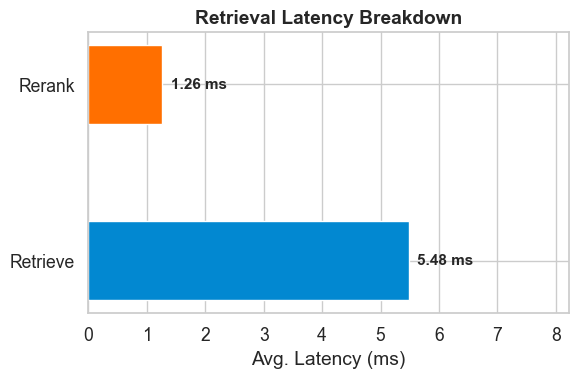

In [3]:
# Latency breakdown
lat = retrieval["latency_breakdown"]
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Retrieve", "Rerank"]
vals   = [lat["retrieve_ms_avg"], lat["rerank_ms_avg"]]
bars = ax.barh(labels, vals, color=[PAL[4], PAL[0]], edgecolor="white", height=0.45)
for b in bars:
    ax.text(b.get_width() + 0.15, b.get_y() + b.get_height()/2,
            f"{b.get_width():.2f} ms", va="center", fontsize=11, fontweight="bold")
ax.set_xlabel("Avg. Latency (ms)"); ax.set_title("Retrieval Latency Breakdown", fontweight="bold")
ax.set_xlim(0, max(vals)*1.5)
plt.tight_layout()
plt.savefig("figures/fig_latency.png", dpi=180, bbox_inches="tight")
plt.show()

---
## 2. LLM-as-Judge Faithfulness Evaluation

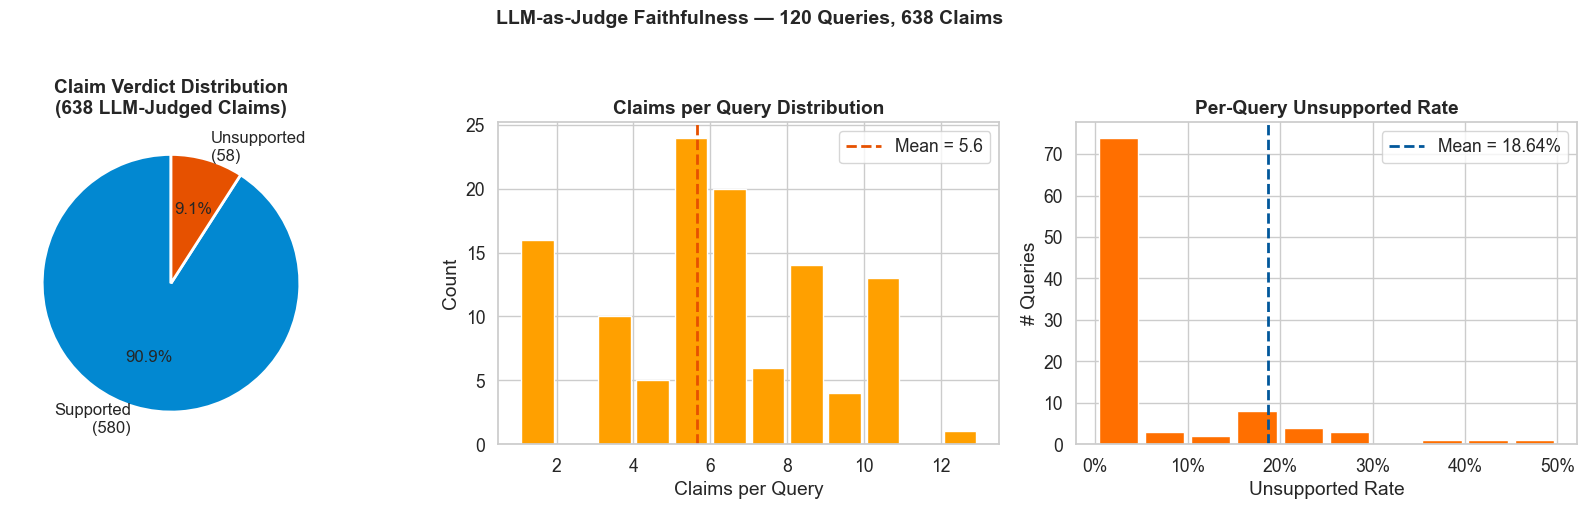

In [4]:
df_claims = pd.DataFrame(claims)
n_sup   = df_claims["supported"].sum()
n_unsup = (~df_claims["supported"]).sum()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Pie: supported vs unsupported
axes[0].pie([n_sup, n_unsup], labels=[f"Supported\n({n_sup})", f"Unsupported\n({n_unsup})"],
            colors=[PAL[4], PAL[6]], autopct="%1.1f%%", startangle=90,
            textprops={"fontsize": 12}, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[0].set_title("Claim Verdict Distribution\n(638 LLM-Judged Claims)", fontweight="bold")

# Claims per query
qcounts = df_claims.groupby("query_id").size()
axes[1].hist(qcounts, bins=range(1, qcounts.max()+2), color=PAL[1], edgecolor="white", rwidth=0.85)
axes[1].axvline(qcounts.mean(), color=PAL[6], ls="--", lw=2, label=f"Mean = {qcounts.mean():.1f}")
axes[1].set_xlabel("Claims per Query"); axes[1].set_ylabel("Count")
axes[1].set_title("Claims per Query Distribution", fontweight="bold")
axes[1].legend()

# Unsupported rate per query
unsup_rate = df_claims.groupby("query_id")["supported"].apply(lambda s: 1 - s.mean())
axes[2].hist(unsup_rate, bins=np.arange(0, 0.55, 0.05), color=PAL[0], edgecolor="white", rwidth=0.85)
axes[2].axvline(unsup_rate.mean(), color=PAL[5], ls="--", lw=2, label=f"Mean = {unsup_rate.mean():.2%}")
axes[2].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[2].set_xlabel("Unsupported Rate"); axes[2].set_ylabel("# Queries")
axes[2].set_title("Per-Query Unsupported Rate", fontweight="bold")
axes[2].legend()

fig.suptitle("LLM-as-Judge Faithfulness — 120 Queries, 638 Claims", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_faithfulness.png", dpi=180, bbox_inches="tight")
plt.show()

---
## 3. MSA Score Distributions (Human-Labeled, 634 Claims)

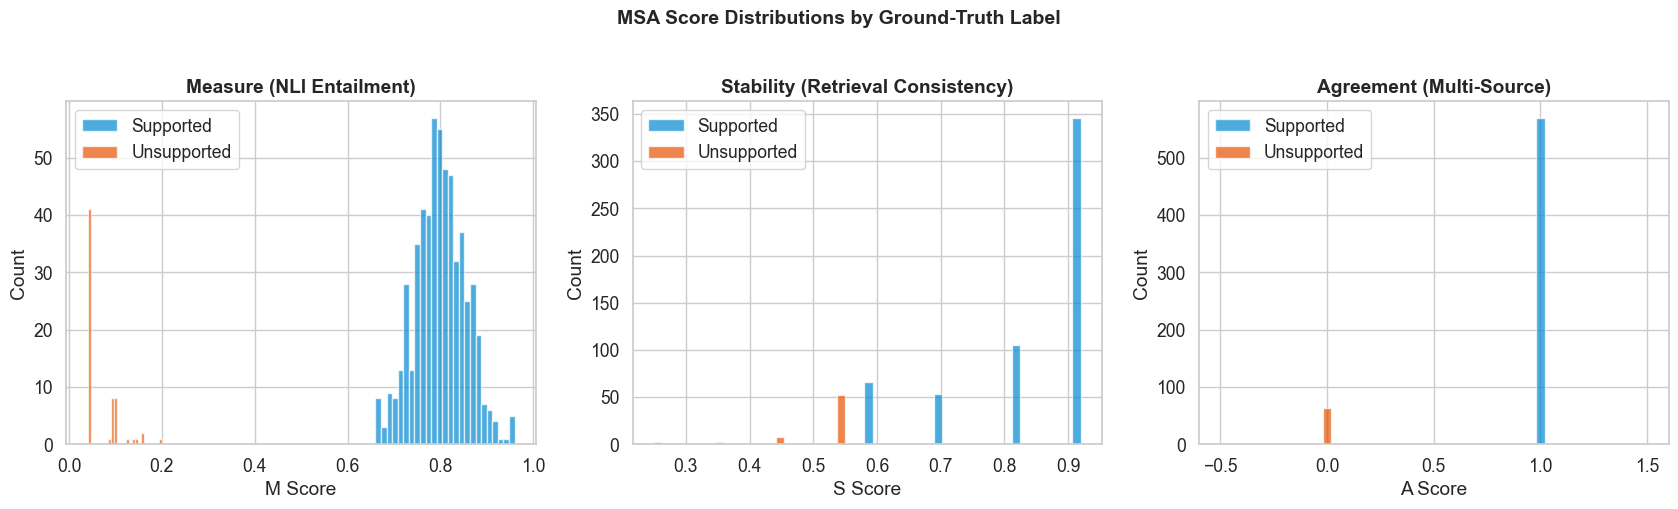

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
components = [("M", "Measure (NLI Entailment)"), ("S", "Stability (Retrieval Consistency)"), ("A", "Agreement (Multi-Source)")]

for ax, (col, title) in zip(axes, components):
    for label, color in [("supported", PAL[4]), ("unsupported", PAL[6])]:
        subset = df_human[df_human["label"] == label][col]
        ax.hist(subset, bins=25, alpha=0.7, color=color, label=label.capitalize(), edgecolor="white")
    ax.set_xlabel(f"{col} Score"); ax.set_ylabel("Count")
    ax.set_title(title, fontweight="bold")
    ax.legend()

fig.suptitle("MSA Score Distributions by Ground-Truth Label", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_msa_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

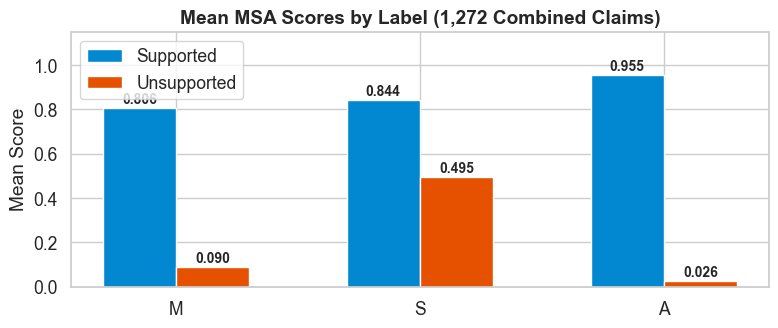

In [6]:
# MSA mean summary table
means = calib["mean_msa_by_label"]
summary_data = {
    "Component": ["Measure (M)", "Stability (S)", "Agreement (A)"],
    "Supported Mean": [means["supported"]["M"], means["supported"]["S"], means["supported"]["A"]],
    "Unsupported Mean": [means["unsupported"]["M"], means["unsupported"]["S"], means["unsupported"]["A"]],
}
df_summary = pd.DataFrame(summary_data)

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(3); w = 0.3
ax.bar(x - w/2, df_summary["Supported Mean"], w, label="Supported", color=PAL[4], edgecolor="white")
ax.bar(x + w/2, df_summary["Unsupported Mean"], w, label="Unsupported", color=PAL[6], edgecolor="white")
for i, (s, u) in enumerate(zip(df_summary["Supported Mean"], df_summary["Unsupported Mean"])):
    ax.text(i - w/2, s + 0.02, f"{s:.3f}", ha="center", fontsize=10, fontweight="bold")
    ax.text(i + w/2, u + 0.02, f"{u:.3f}", ha="center", fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(["M", "S", "A"])
ax.set_ylabel("Mean Score"); ax.set_ylim(0, 1.15)
ax.set_title("Mean MSA Scores by Label (1,272 Combined Claims)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("figures/fig_msa_means.png", dpi=180, bbox_inches="tight")
plt.show()

---
## 4. Calibration & Ablation Study

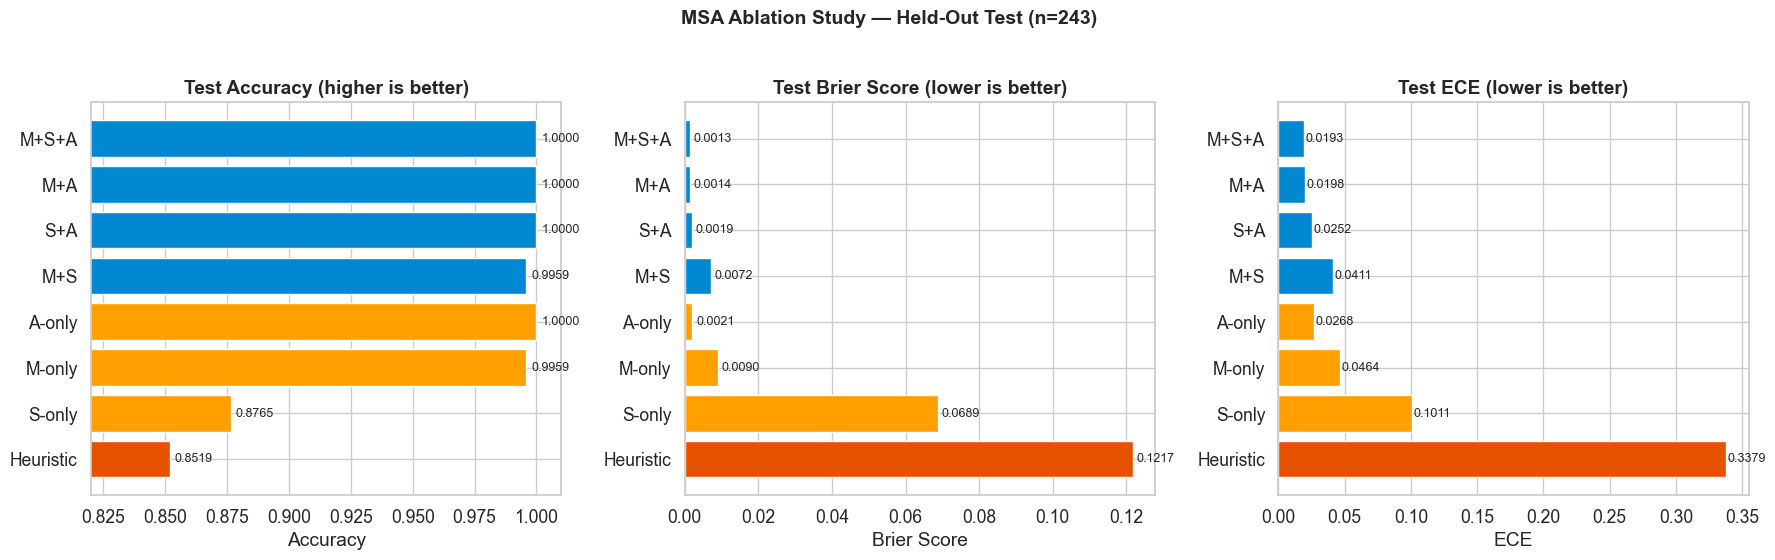


Full Ablation Table:


,Model,Test Accuracy,Test Brier,Test ECE,Train Accuracy,Train Brier,Train ECE
0,M+S+A,1.0000,0.0013,0.0193,1.0000,0.0007,0.0127
1,M+A,1.0000,0.0014,0.0198,1.0000,0.0007,0.0131
2,S+A,1.0000,0.0019,0.0252,1.0000,0.0012,0.0174
3,M+S,0.9959,0.0072,0.0411,1.0000,0.0030,0.0267
4,A-only,1.0000,0.0021,0.0268,1.0000,0.0013,0.0186
5,M-only,0.9959,0.0090,0.0464,1.0000,0.0037,0.0301
6,S-only,0.8765,0.0689,0.1011,0.9339,0.0412,0.0692
7,Heuristic,0.8519,0.1217,0.3379,0.9164,0.1074,0.3206


In [7]:
models_order = ["M+S+A", "M+A", "S+A", "M+S", "A-only", "M-only", "S-only", "Heuristic"]
metrics_names = ["accuracy", "brier", "ece"]

rows = []
for m in models_order:
    d = calib["models"][m]
    rows.append({
        "Model": m,
        "Test Accuracy": d["test"]["accuracy"],
        "Test Brier":    d["test"]["brier"],
        "Test ECE":      d["test"]["ece"],
        "Train Accuracy": d["train"]["accuracy"],
        "Train Brier":    d["train"]["brier"],
        "Train ECE":      d["train"]["ece"],
    })
df_ab = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
colors_bar = [PAL[4]]*4 + [PAL[1]]*3 + [PAL[6]]

# Accuracy
bars = axes[0].barh(df_ab["Model"], df_ab["Test Accuracy"], color=colors_bar, edgecolor="white")
for b in bars:
    axes[0].text(b.get_width() + 0.002, b.get_y() + b.get_height()/2,
                 f"{b.get_width():.4f}", va="center", fontsize=9)
axes[0].set_xlim(0.82, 1.01); axes[0].set_xlabel("Accuracy")
axes[0].set_title("Test Accuracy (higher is better)", fontweight="bold")
axes[0].invert_yaxis()

# Brier
bars = axes[1].barh(df_ab["Model"], df_ab["Test Brier"], color=colors_bar, edgecolor="white")
for b in bars:
    axes[1].text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
                 f"{b.get_width():.4f}", va="center", fontsize=9)
axes[1].set_xlabel("Brier Score")
axes[1].set_title("Test Brier Score (lower is better)", fontweight="bold")
axes[1].invert_yaxis()

# ECE
bars = axes[2].barh(df_ab["Model"], df_ab["Test ECE"], color=colors_bar, edgecolor="white")
for b in bars:
    axes[2].text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
                 f"{b.get_width():.4f}", va="center", fontsize=9)
axes[2].set_xlabel("ECE")
axes[2].set_title("Test ECE (lower is better)", fontweight="bold")
axes[2].invert_yaxis()

fig.suptitle(f"MSA Ablation Study — Held-Out Test (n={calib['test_size']})", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_ablation.png", dpi=180, bbox_inches="tight")
plt.show()

print("\nFull Ablation Table:")
display(df_ab.style.format({
    "Test Accuracy": "{:.4f}", "Test Brier": "{:.4f}", "Test ECE": "{:.4f}",
    "Train Accuracy": "{:.4f}", "Train Brier": "{:.4f}", "Train ECE": "{:.4f}"
}).set_caption("Ablation Study — All Feature Combinations"))

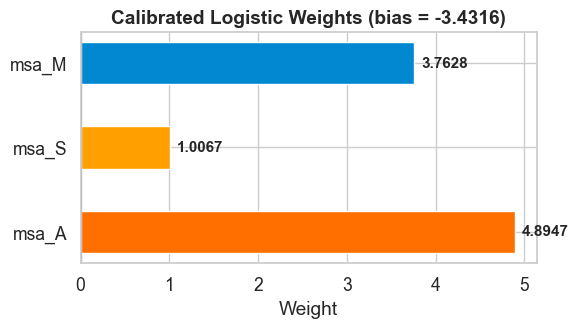

In [8]:
# Logistic regression weights for the full M+S+A model
full_model = calib["models"]["M+S+A"]
w_names = list(full_model["weights"].keys())
w_vals  = list(full_model["weights"].values())

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.barh(w_names, w_vals, color=[PAL[4], PAL[1], PAL[0]], edgecolor="white", height=0.5)
for b in bars:
    ax.text(b.get_width() + 0.08, b.get_y() + b.get_height()/2,
            f"{b.get_width():.4f}", va="center", fontsize=11, fontweight="bold")
ax.axvline(0, color="grey", lw=0.8)
ax.set_xlabel("Weight"); ax.set_title(f"Calibrated Logistic Weights (bias = {full_model['bias']:.4f})", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("figures/fig_weights.png", dpi=180, bbox_inches="tight")
plt.show()

---
## 5. Inter-Annotator Agreement (IAA)

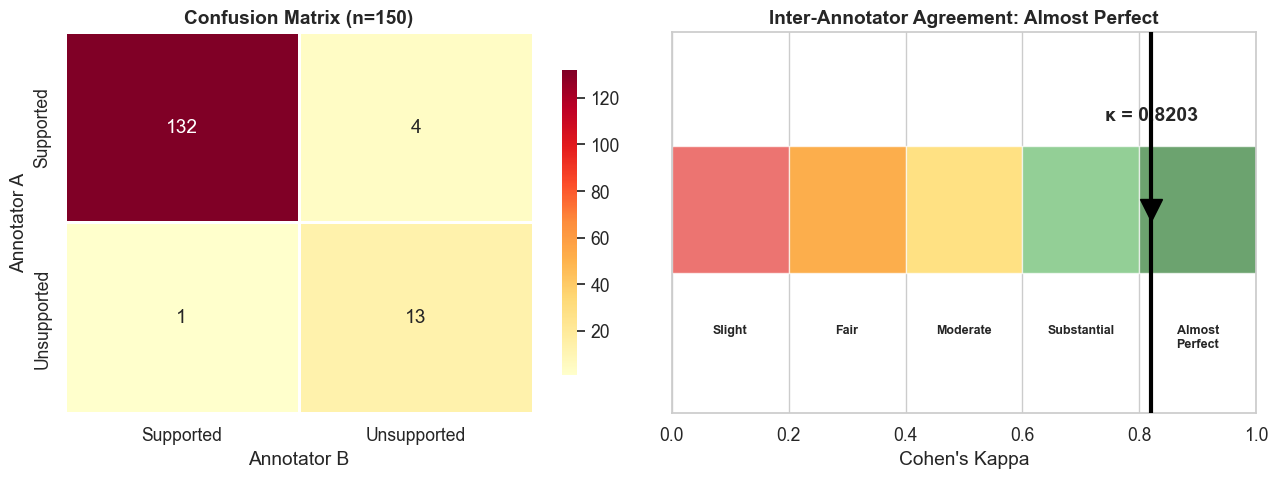

Agreement: 145/150 (96.67%)
Cohen's kappa: 0.8203 — almost perfect


In [9]:
cm = iaa["confusion_matrix"]
conf_mat = np.array([[cm["sup_sup"], cm["sup_unsup"]],
                     [cm["unsup_sup"], cm["unsup_unsup"]]])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Heatmap
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=["Supported", "Unsupported"],
            yticklabels=["Supported", "Unsupported"],
            ax=axes[0], cbar_kws={"shrink": 0.8}, linewidths=2, linecolor="white")
axes[0].set_xlabel("Annotator B"); axes[0].set_ylabel("Annotator A")
axes[0].set_title(f"Confusion Matrix (n={iaa['n']})", fontweight="bold")

# Kappa gauge
kappa = iaa["cohens_kappa"]
kappa_ranges = [(0, 0.20, "Slight"), (0.20, 0.40, "Fair"),
                (0.40, 0.60, "Moderate"), (0.60, 0.80, "Substantial"),
                (0.80, 1.00, "Almost\nPerfect")]
colors_kappa = ["#E53935", "#FB8C00", "#FFD54F", "#66BB6A", "#2E7D32"]

for (lo, hi, lbl), col in zip(kappa_ranges, colors_kappa):
    axes[1].barh(0, hi - lo, left=lo, height=0.5, color=col, edgecolor="white", alpha=0.7)
    axes[1].text((lo + hi)/2, -0.45, lbl, ha="center", va="top", fontsize=9, fontweight="bold")

axes[1].axvline(kappa, color="black", lw=3, zorder=5)
axes[1].plot(kappa, 0, marker="v", color="black", markersize=16, zorder=6)
axes[1].text(kappa, 0.35, f"κ = {kappa:.4f}", ha="center", fontsize=14, fontweight="bold")

axes[1].set_xlim(0, 1); axes[1].set_ylim(-0.8, 0.7)
axes[1].set_xlabel("Cohen's Kappa"); axes[1].set_yticks([])
axes[1].set_title(f"Inter-Annotator Agreement: {iaa['interpretation'].title()}", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig_iaa.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Agreement: {iaa['agreement_count']}/{iaa['n']} ({iaa['agreement_pct']}%)")
print(f"Cohen's kappa: {kappa:.4f} — {iaa['interpretation']}")

---
## 6. Public Research Mode — Live API Evaluation (20 Queries, 6 Providers)

Public search evaluation: 20 queries, 200 total results



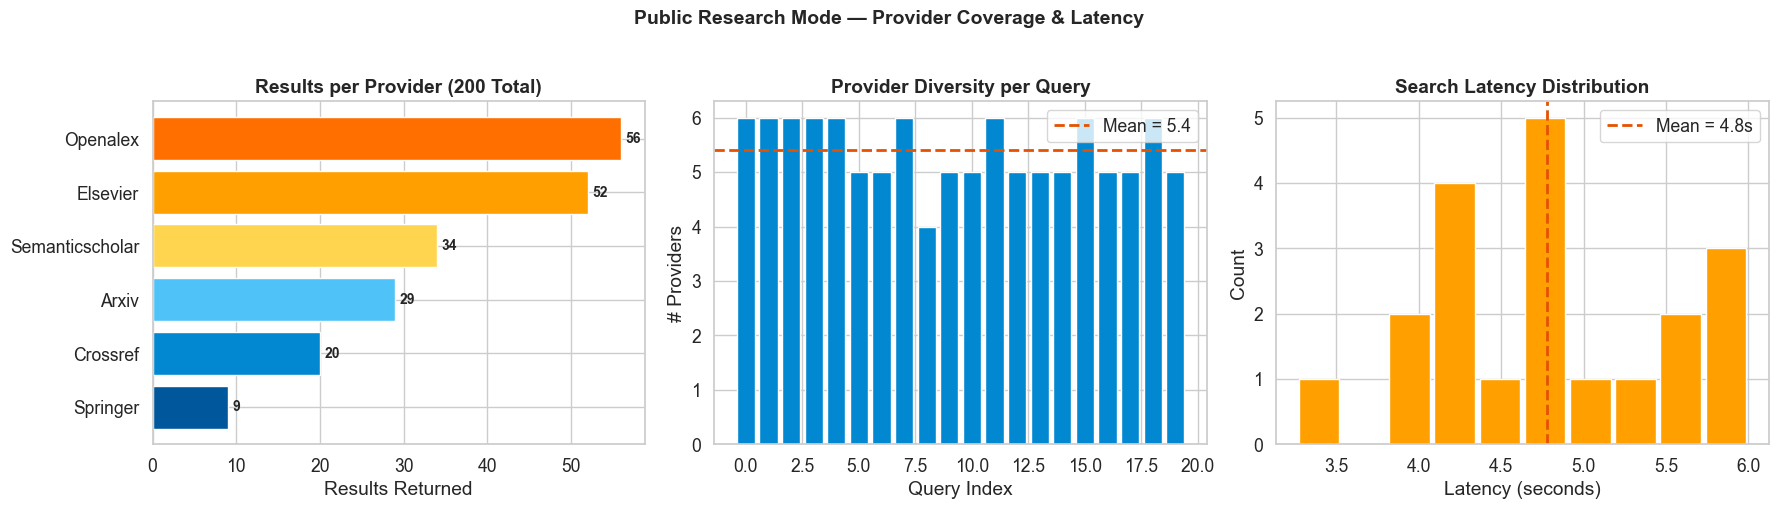

In [10]:
pub_data = json.loads((DATA / "public_search/public_search_eval.json").read_text())
print(f"Public search evaluation: {len(pub_data)} queries, {sum(r['result_count'] for r in pub_data)} total results\n")

# --- Provider coverage ---
all_providers_pub = set()
provider_counts = Counter()
provider_per_query = []
for r in pub_data:
    providers_in_q = set()
    for res in r["results"]:
        src = (res.get("source") or "unknown").lower()
        provider_counts[src] += 1
        providers_in_q.add(src)
    all_providers_pub.update(providers_in_q)
    provider_per_query.append(len(providers_in_q))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Provider distribution (total results)
sorted_providers = sorted(provider_counts.items(), key=lambda x: -x[1])
prov_names = [p[0].title() for p in sorted_providers]
prov_vals  = [p[1] for p in sorted_providers]
prov_colors = [PAL[i % len(PAL)] for i in range(len(sorted_providers))]
bars = axes[0].barh(prov_names, prov_vals, color=prov_colors, edgecolor="white")
for b in bars:
    axes[0].text(b.get_width() + 0.5, b.get_y() + b.get_height()/2,
                 str(int(b.get_width())), va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Results Returned"); axes[0].invert_yaxis()
axes[0].set_title("Results per Provider (200 Total)", fontweight="bold")

# Provider diversity per query
axes[1].bar(range(len(provider_per_query)), provider_per_query, color=PAL[4], edgecolor="white")
axes[1].axhline(np.mean(provider_per_query), color=PAL[6], ls="--", lw=2,
                label=f"Mean = {np.mean(provider_per_query):.1f}")
axes[1].set_xlabel("Query Index"); axes[1].set_ylabel("# Providers")
axes[1].set_title("Provider Diversity per Query", fontweight="bold")
axes[1].legend()

# Latency distribution
latencies = [r["latency_s"] for r in pub_data]
axes[2].hist(latencies, bins=10, color=PAL[1], edgecolor="white", rwidth=0.9)
axes[2].axvline(np.mean(latencies), color=PAL[6], ls="--", lw=2,
                label=f"Mean = {np.mean(latencies):.1f}s")
axes[2].set_xlabel("Latency (seconds)"); axes[2].set_ylabel("Count")
axes[2].set_title("Search Latency Distribution", fontweight="bold")
axes[2].legend()

fig.suptitle("Public Research Mode — Provider Coverage & Latency", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_public_providers.png", dpi=180, bbox_inches="tight")
plt.show()

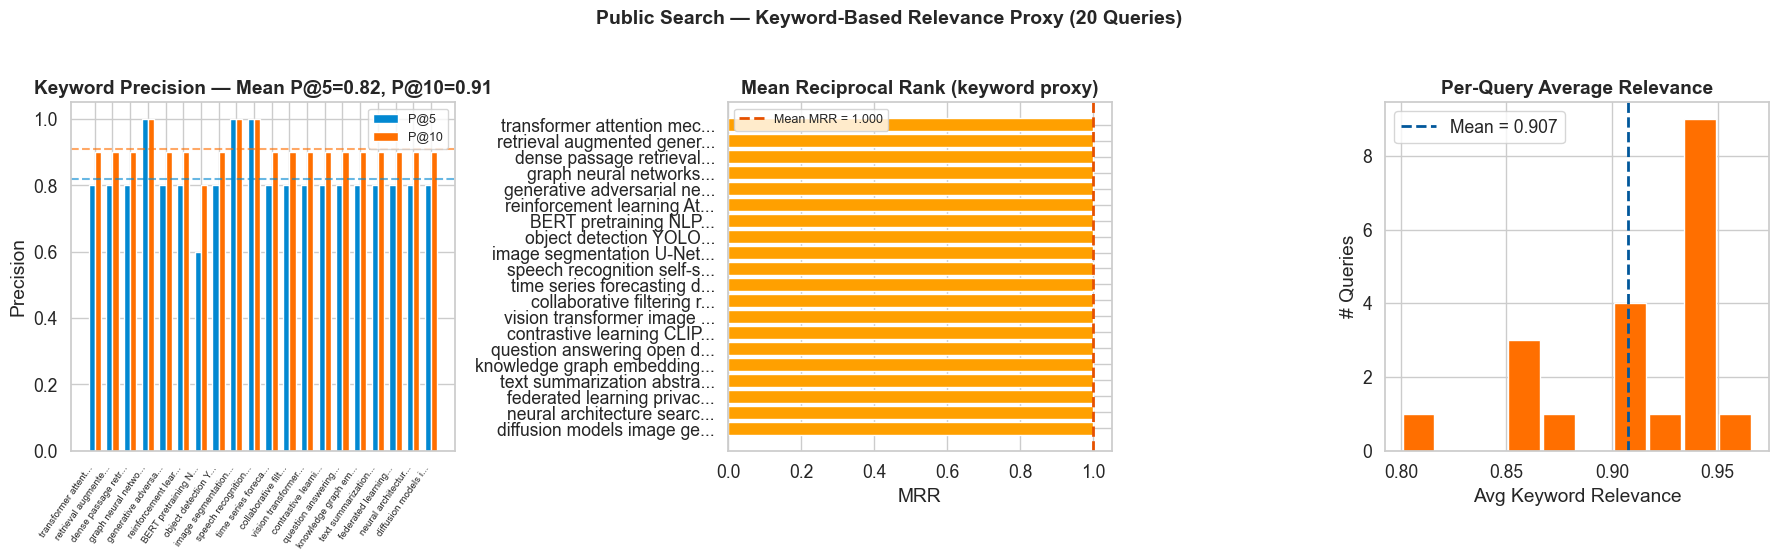


Public Search Relevance Summary:
  Mean Precision@5:  0.820
  Mean Precision@10: 0.910
  Mean MRR:          1.000
  Mean Relevance:    0.907


In [11]:
import re as _re

def _keyword_relevance(query: str, title: str, abstract: str) -> float:
    """Proxy relevance: fraction of query keywords found in title+abstract."""
    stop = {"the","and","for","with","that","this","from","into","using","how","what","why","does","can"}
    q_toks = {t for t in _re.findall(r"[a-z0-9]+", query.lower()) if len(t) > 2 and t not in stop}
    if not q_toks:
        return 0.0
    text = f"{title} {abstract}".lower()
    return sum(1 for t in q_toks if t in text) / len(q_toks)

# Compute proxy relevance for every result
all_relevances = []
per_query_precision = []
per_query_data = []

for r in pub_data:
    query = r["query"]
    rels = []
    for res in r["results"]:
        title = res.get("title", "") or ""
        abstract = res.get("summary", "") or ""
        rel = _keyword_relevance(query, title, abstract)
        rels.append(rel)
        all_relevances.append({"query": query, "title": title[:60], "source": res.get("source","?"), "relevance": rel})
    # Precision@K: fraction of results with relevance > threshold
    p_at_5 = sum(1 for r in rels[:5] if r >= 0.5) / 5 if len(rels) >= 5 else 0
    p_at_10 = sum(1 for r in rels[:10] if r >= 0.5) / max(1, min(10, len(rels)))
    mrr = 0.0
    for rank, rel in enumerate(rels, 1):
        if rel >= 0.5:
            mrr = 1.0 / rank
            break
    per_query_data.append({
        "query": query, "p@5": p_at_5, "p@10": p_at_10, "mrr": mrr,
        "avg_rel": np.mean(rels) if rels else 0, "n_results": len(rels)
    })

df_pq = pd.DataFrame(per_query_data)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Precision@5 and @10
x = np.arange(len(df_pq)); w = 0.35
axes[0].bar(x - w/2, df_pq["p@5"],  w, label="P@5",  color=PAL[4], edgecolor="white")
axes[0].bar(x + w/2, df_pq["p@10"], w, label="P@10", color=PAL[0], edgecolor="white")
axes[0].axhline(df_pq["p@5"].mean(), color=PAL[4], ls="--", lw=1.5, alpha=0.6)
axes[0].axhline(df_pq["p@10"].mean(), color=PAL[0], ls="--", lw=1.5, alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels([q[:18]+"..." for q in df_pq["query"]], rotation=55, ha="right", fontsize=7)
axes[0].set_ylabel("Precision"); axes[0].set_ylim(0, 1.05)
axes[0].set_title(f"Keyword Precision — Mean P@5={df_pq['p@5'].mean():.2f}, P@10={df_pq['p@10'].mean():.2f}", fontweight="bold")
axes[0].legend(fontsize=9)

# MRR
bars = axes[1].barh(df_pq["query"].str[:25]+"...", df_pq["mrr"], color=PAL[1], edgecolor="white")
axes[1].axvline(df_pq["mrr"].mean(), color=PAL[6], ls="--", lw=2,
                label=f"Mean MRR = {df_pq['mrr'].mean():.3f}")
axes[1].set_xlabel("MRR"); axes[1].invert_yaxis()
axes[1].set_title("Mean Reciprocal Rank (keyword proxy)", fontweight="bold")
axes[1].legend(fontsize=9)

# Average relevance distribution
axes[2].hist(df_pq["avg_rel"], bins=10, color=PAL[0], edgecolor="white", rwidth=0.9)
axes[2].axvline(df_pq["avg_rel"].mean(), color=PAL[5], ls="--", lw=2,
                label=f"Mean = {df_pq['avg_rel'].mean():.3f}")
axes[2].set_xlabel("Avg Keyword Relevance"); axes[2].set_ylabel("# Queries")
axes[2].set_title("Per-Query Average Relevance", fontweight="bold")
axes[2].legend()

fig.suptitle("Public Search — Keyword-Based Relevance Proxy (20 Queries)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_public_relevance.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\nPublic Search Relevance Summary:")
print(f"  Mean Precision@5:  {df_pq['p@5'].mean():.3f}")
print(f"  Mean Precision@10: {df_pq['p@10'].mean():.3f}")
print(f"  Mean MRR:          {df_pq['mrr'].mean():.3f}")
print(f"  Mean Relevance:    {df_pq['avg_rel'].mean():.3f}")

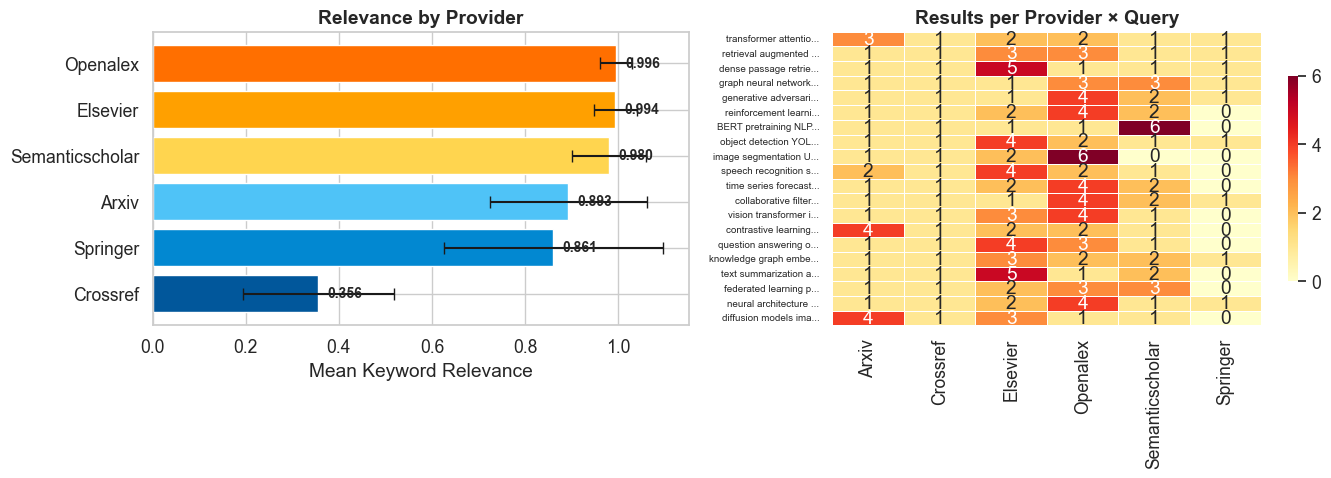

Provider,Mean Relevance,Results,Std
openalex,0.996,56,0.033
elsevier,0.994,52,0.046
semanticscholar,0.980,34,0.080
arxiv,0.893,29,0.169
springer,0.861,9,0.236
crossref,0.356,20,0.162


In [12]:
# Provider-level relevance breakdown
df_all_rel = pd.DataFrame(all_relevances)
provider_rel = df_all_rel.groupby("source")["relevance"].agg(["mean", "count", "std"]).reset_index()
provider_rel.columns = ["Provider", "Mean Relevance", "Results", "Std"]
provider_rel = provider_rel.sort_values("Mean Relevance", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Provider-level mean relevance
bars = axes[0].barh(provider_rel["Provider"].str.title(), provider_rel["Mean Relevance"],
                     xerr=provider_rel["Std"], color=PAL[:len(provider_rel)], edgecolor="white",
                     capsize=4)
for b, val in zip(bars, provider_rel["Mean Relevance"]):
    axes[0].text(b.get_width() + 0.02, b.get_y() + b.get_height()/2,
                 f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
axes[0].set_xlabel("Mean Keyword Relevance"); axes[0].invert_yaxis()
axes[0].set_title("Relevance by Provider", fontweight="bold")

# Heatmap: query vs provider availability
query_provider_matrix = []
short_queries = [q[:20]+"..." for q in [r["query"] for r in pub_data]]
for r in pub_data:
    row_providers = Counter(res.get("source", "?") for res in r["results"])
    query_provider_matrix.append(row_providers)

all_prov_names = sorted(all_providers_pub)
matrix = np.zeros((len(pub_data), len(all_prov_names)))
for i, row in enumerate(query_provider_matrix):
    for j, prov in enumerate(all_prov_names):
        matrix[i][j] = row.get(prov, 0)

sns.heatmap(matrix, xticklabels=[p.title() for p in all_prov_names],
            yticklabels=short_queries, cmap="YlOrRd", annot=True, fmt=".0f",
            ax=axes[1], linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.7})
axes[1].set_title("Results per Provider × Query", fontweight="bold")
axes[1].tick_params(axis="y", labelsize=7)

plt.tight_layout()
plt.savefig("figures/fig_public_provider_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()

display(provider_rel.style.format({
    "Mean Relevance": "{:.3f}", "Std": "{:.3f}", "Results": "{:.0f}"
}).set_caption("Provider-Level Keyword Relevance").hide(axis="index"))

---
## 7. Combined Summary Dashboard

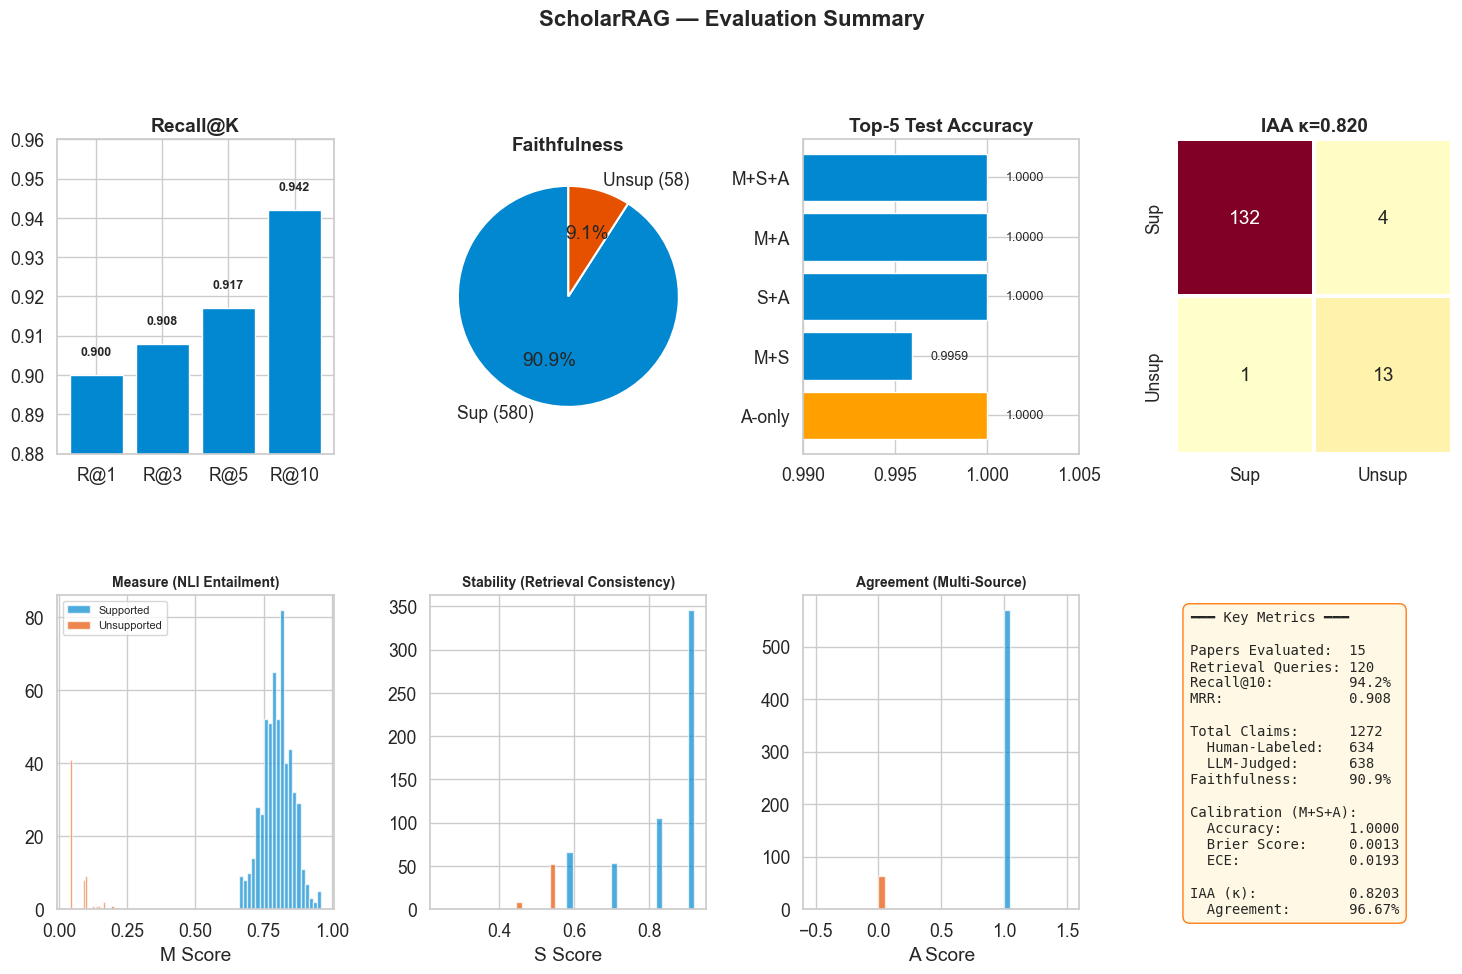

In [13]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.35)

# (0,0) Recall@K radar-style bar
ax1 = fig.add_subplot(gs[0, 0])
ks_all = ["1", "3", "5", "10"]
vals_r = [retrieval["metrics_retrieval_only"]["recall_at"][k] for k in ks_all]
ax1.bar([f"R@{k}" for k in ks_all], vals_r, color=PAL[4], edgecolor="white")
for i, v in enumerate(vals_r):
    ax1.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")
ax1.set_ylim(0.88, 0.96); ax1.set_title("Recall@K", fontweight="bold")

# (0,1) Faithfulness pie
ax2 = fig.add_subplot(gs[0, 1])
ax2.pie([n_sup, n_unsup], labels=[f"Sup ({n_sup})", f"Unsup ({n_unsup})"],
        colors=[PAL[4], PAL[6]], autopct="%1.1f%%", startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 1.5})
ax2.set_title("Faithfulness", fontweight="bold")

# (0,2) Ablation accuracy
ax3 = fig.add_subplot(gs[0, 2])
top4 = df_ab.head(5)
bars = ax3.barh(top4["Model"], top4["Test Accuracy"],
                color=[PAL[4]]*4 + [PAL[1]], edgecolor="white")
for b in bars:
    ax3.text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
             f"{b.get_width():.4f}", va="center", fontsize=9)
ax3.set_xlim(0.99, 1.005); ax3.set_title("Top-5 Test Accuracy", fontweight="bold")
ax3.invert_yaxis()

# (0,3) IAA
ax4 = fig.add_subplot(gs[0, 3])
sns.heatmap(conf_mat, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=["Sup", "Unsup"], yticklabels=["Sup", "Unsup"],
            ax=ax4, cbar=False, linewidths=1.5, linecolor="white")
ax4.set_title(f"IAA κ={kappa:.3f}", fontweight="bold")

# (1, 0:2) MSA distributions
for i, (col, title) in enumerate(components):
    ax = fig.add_subplot(gs[1, i])
    for label, color in [("supported", PAL[4]), ("unsupported", PAL[6])]:
        subset = df_human[df_human["label"] == label][col]
        ax.hist(subset, bins=20, alpha=0.7, color=color, label=label.capitalize(), edgecolor="white")
    ax.set_xlabel(f"{col} Score"); ax.set_title(title, fontweight="bold", fontsize=10)
    if i == 0: ax.legend(fontsize=8)

# (1, 3) Key metrics text
ax5 = fig.add_subplot(gs[1, 3])
ax5.axis("off")
metrics_text = (
    f"━━━ Key Metrics ━━━\n\n"
    f"Papers Evaluated:  15\n"
    f"Retrieval Queries: 120\n"
    f"Recall@10:         {retrieval['metrics_retrieval_only']['recall_at']['10']:.1%}\n"
    f"MRR:               {retrieval['metrics_retrieval_only']['mrr']:.3f}\n\n"
    f"Total Claims:      {len(claims) + len(df_human)}\n"
    f"  Human-Labeled:   {len(df_human)}\n"
    f"  LLM-Judged:      {len(claims)}\n"
    f"Faithfulness:      {n_sup/(n_sup+n_unsup):.1%}\n\n"
    f"Calibration (M+S+A):\n"
    f"  Accuracy:        {calib['models']['M+S+A']['test']['accuracy']:.4f}\n"
    f"  Brier Score:     {calib['models']['M+S+A']['test']['brier']:.4f}\n"
    f"  ECE:             {calib['models']['M+S+A']['test']['ece']:.4f}\n\n"
    f"IAA (κ):           {kappa:.4f}\n"
    f"  Agreement:       {iaa['agreement_pct']}%"
)
ax5.text(0.05, 0.95, metrics_text, transform=ax5.transAxes, fontsize=10,
         va="top", ha="left", fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFF8E1", edgecolor="#FF6F00", alpha=0.9))

fig.suptitle("ScholarRAG — Evaluation Summary", fontsize=16, fontweight="bold", y=1.01)
plt.savefig("figures/fig_summary_dashboard.png", dpi=180, bbox_inches="tight")
plt.show()

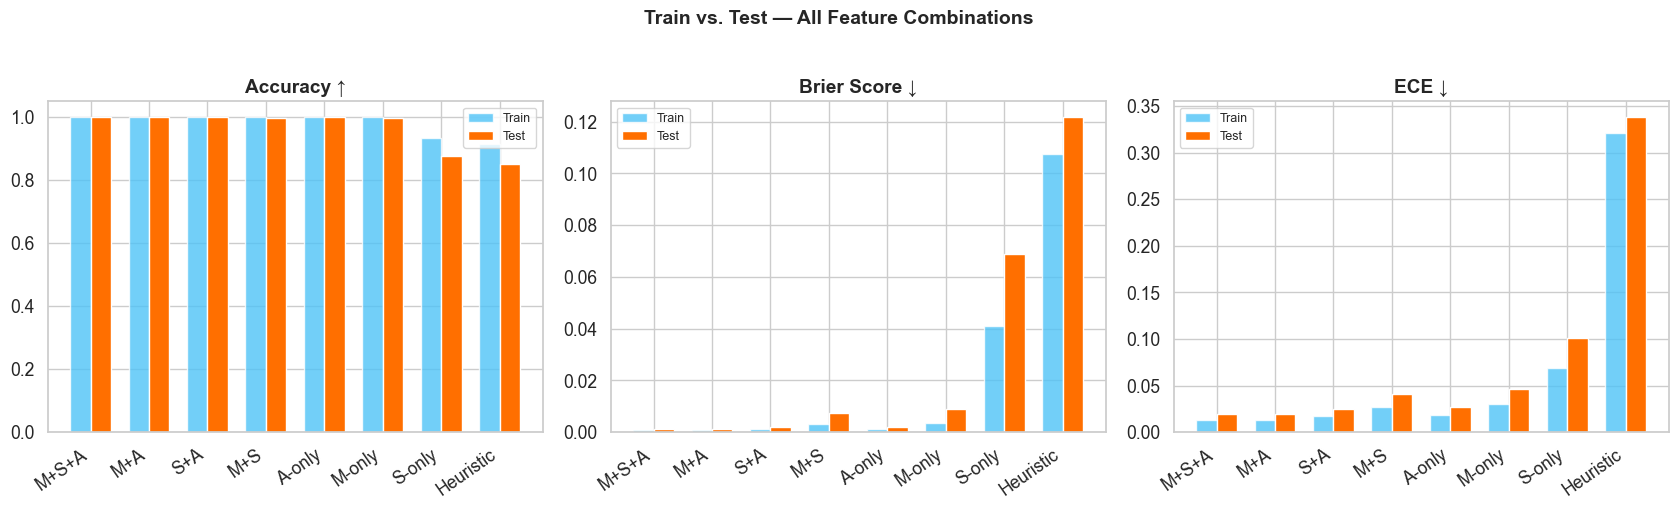

In [14]:
# Train vs Test comparison
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metric_pairs = [("accuracy", "Accuracy ↑"), ("brier", "Brier Score ↓"), ("ece", "ECE ↓")]

for ax, (metric, title) in zip(axes, metric_pairs):
    train_vals = [calib["models"][m]["train"][metric] for m in models_order]
    test_vals  = [calib["models"][m]["test"][metric]  for m in models_order]
    x = np.arange(len(models_order)); w = 0.35
    ax.bar(x - w/2, train_vals, w, label="Train", color=PAL[3], edgecolor="white", alpha=0.8)
    ax.bar(x + w/2, test_vals,  w, label="Test",  color=PAL[0], edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(models_order, rotation=35, ha="right")
    ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9)

fig.suptitle("Train vs. Test — All Feature Combinations", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_train_vs_test.png", dpi=180, bbox_inches="tight")
plt.show()

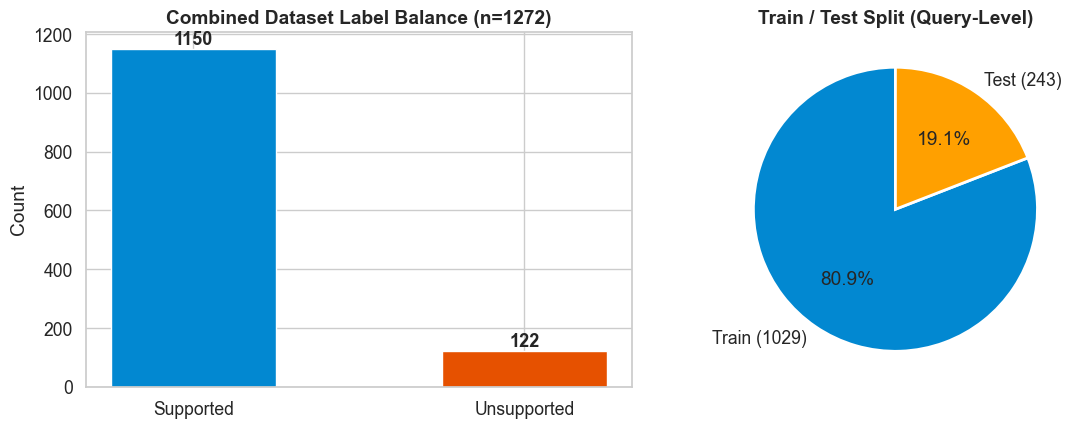


Total dataset: 1272 claims
  Supported: 1150 (90.4%)
  Unsupported: 122 (9.6%)
  Train: 1029 (128 queries)
  Test: 243 (33 queries)


In [15]:
# Dataset composition
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Label balance
axes[0].bar(["Supported", "Unsupported"], [calib["supported"], calib["unsupported"]],
            color=[PAL[4], PAL[6]], edgecolor="white", width=0.5)
axes[0].text(0, calib["supported"] + 15, str(calib["supported"]), ha="center", fontsize=13, fontweight="bold")
axes[0].text(1, calib["unsupported"] + 15, str(calib["unsupported"]), ha="center", fontsize=13, fontweight="bold")
axes[0].set_title(f"Combined Dataset Label Balance (n={calib['dataset_size']})", fontweight="bold")
axes[0].set_ylabel("Count")

# Train/Test split
axes[1].pie([calib["train_size"], calib["test_size"]],
            labels=[f"Train ({calib['train_size']})", f"Test ({calib['test_size']})"],
            colors=[PAL[4], PAL[1]], autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Train / Test Split (Query-Level)", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/fig_dataset.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"\nTotal dataset: {calib['dataset_size']} claims")
print(f"  Supported: {calib['supported']} ({calib['supported']/calib['dataset_size']:.1%})")
print(f"  Unsupported: {calib['unsupported']} ({calib['unsupported']/calib['dataset_size']:.1%})")
print(f"  Train: {calib['train_size']} ({calib['train_queries']} queries)")
print(f"  Test: {calib['test_size']} ({calib['test_queries']} queries)")

---
## 8. Confidence Score Distribution (LLM-Judged Answers)

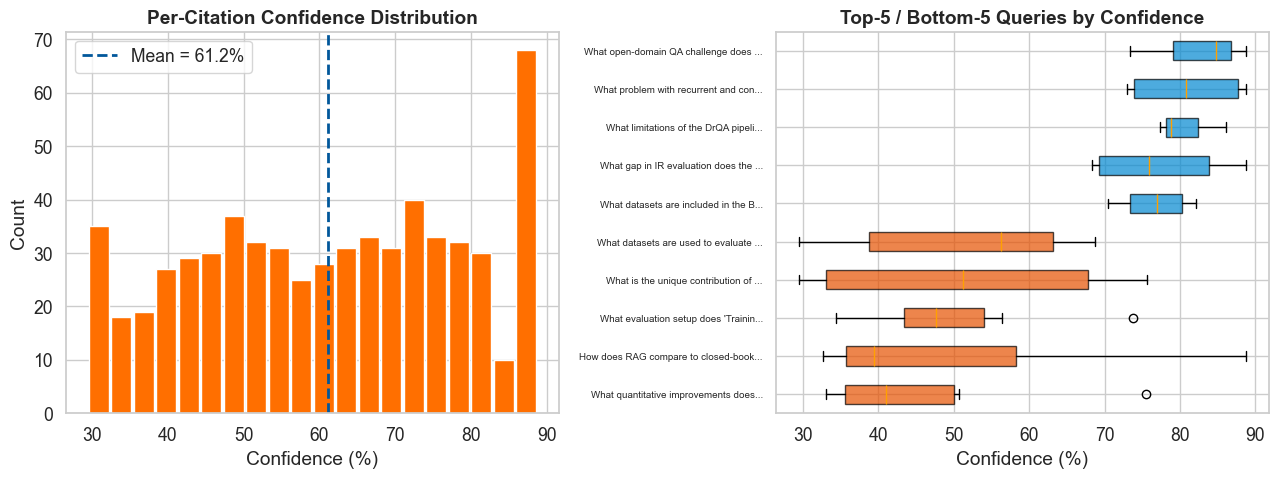

Total citations with confidence: 619
Mean confidence: 61.2%, Median: 61.8%


In [16]:
# Extract confidence scores from judge results
conf_scores = []
for d in judge_raw.get("details", []):
    for cit in d.get("citations", []):
        if "confidence_percent" in cit:
            conf_scores.append(cit["confidence_percent"])
        elif "confidence" in cit and isinstance(cit["confidence"], (int, float)):
            conf_scores.append(cit["confidence"] * 100)

if conf_scores:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    axes[0].hist(conf_scores, bins=20, color=PAL[0], edgecolor="white", rwidth=0.9)
    axes[0].axvline(np.mean(conf_scores), color=PAL[5], ls="--", lw=2,
                    label=f"Mean = {np.mean(conf_scores):.1f}%")
    axes[0].set_xlabel("Confidence (%)"); axes[0].set_ylabel("Count")
    axes[0].set_title("Per-Citation Confidence Distribution", fontweight="bold")
    axes[0].legend()
    
    # Box plot by query
    query_confs = {}
    for d in judge_raw.get("details", []):
        q = d.get("query", "")[:40]
        for cit in d.get("citations", []):
            c = cit.get("confidence_percent", cit.get("confidence", 0))
            if isinstance(c, (int, float)):
                if c <= 1: c *= 100
                query_confs.setdefault(q, []).append(c)
    
    if query_confs:
        means = sorted(query_confs.items(), key=lambda x: np.mean(x[1]))
        bottom_5 = means[:5]
        top_5 = means[-5:]
        show = bottom_5 + top_5
        labels = [s[0][:35]+"..." for s in show]
        data = [s[1] for s in show]
        bp = axes[1].boxplot(data, vert=False, patch_artist=True)
        colors_box = [PAL[6]]*5 + [PAL[4]]*5
        for patch, color in zip(bp["boxes"], colors_box):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        axes[1].set_yticklabels(labels, fontsize=7)
        axes[1].set_xlabel("Confidence (%)")
        axes[1].set_title("Top-5 / Bottom-5 Queries by Confidence", fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("figures/fig_confidence_dist.png", dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Total citations with confidence: {len(conf_scores)}")
    print(f"Mean confidence: {np.mean(conf_scores):.1f}%, Median: {np.median(conf_scores):.1f}%")
else:
    print("No per-citation confidence scores found in judge results.")

---
## 9. Summary Statistics Table

In [17]:
summary_table = pd.DataFrame([
    {"Category": "Retrieval (Uploaded)", "Metric": "Recall@1",  "Value": f"{retrieval['metrics_retrieval_only']['recall_at']['1']:.3f}"},
    {"Category": "Retrieval (Uploaded)", "Metric": "Recall@5",  "Value": f"{retrieval['metrics_retrieval_only']['recall_at']['5']:.3f}"},
    {"Category": "Retrieval (Uploaded)", "Metric": "Recall@10", "Value": f"{retrieval['metrics_retrieval_only']['recall_at']['10']:.3f}"},
    {"Category": "Retrieval (Uploaded)", "Metric": "MRR",       "Value": f"{retrieval['metrics_retrieval_only']['mrr']:.3f}"},
    {"Category": "Retrieval (Uploaded)", "Metric": "Avg Retrieve Latency", "Value": f"{retrieval['latency_breakdown']['retrieve_ms_avg']:.2f} ms"},
    {"Category": "Public Research", "Metric": "Queries Tested",        "Value": str(len(pub_data))},
    {"Category": "Public Research", "Metric": "Total Results",         "Value": str(sum(r['result_count'] for r in pub_data))},
    {"Category": "Public Research", "Metric": "Active Providers",      "Value": str(len(all_providers_pub))},
    {"Category": "Public Research", "Metric": "Mean Precision@5 (kw)", "Value": f"{df_pq['p@5'].mean():.3f}"},
    {"Category": "Public Research", "Metric": "Mean Precision@10 (kw)","Value": f"{df_pq['p@10'].mean():.3f}"},
    {"Category": "Public Research", "Metric": "Mean MRR (kw proxy)",   "Value": f"{df_pq['mrr'].mean():.3f}"},
    {"Category": "Public Research", "Metric": "Avg Latency",           "Value": f"{np.mean([r['latency_s'] for r in pub_data]):.1f}s"},
    {"Category": "Faithfulness", "Metric": "LLM-Judged Claims", "Value": str(len(claims))},
    {"Category": "Faithfulness", "Metric": "Support Rate", "Value": f"{n_sup/(n_sup+n_unsup):.1%}"},
    {"Category": "Calibration", "Metric": "Dataset Size", "Value": str(calib["dataset_size"])},
    {"Category": "Calibration", "Metric": "Test Accuracy (M+S+A)", "Value": f"{calib['models']['M+S+A']['test']['accuracy']:.4f}"},
    {"Category": "Calibration", "Metric": "Test Brier (M+S+A)",   "Value": f"{calib['models']['M+S+A']['test']['brier']:.4f}"},
    {"Category": "Calibration", "Metric": "Test ECE (M+S+A)",     "Value": f"{calib['models']['M+S+A']['test']['ece']:.4f}"},
    {"Category": "IAA", "Metric": "Cohen's Kappa", "Value": f"{iaa['cohens_kappa']:.4f}"},
    {"Category": "IAA", "Metric": "Agreement",     "Value": f"{iaa['agreement_pct']}%"},
    {"Category": "IAA", "Metric": "Interpretation", "Value": iaa["interpretation"]},
])

display(summary_table.style.set_properties(**{"text-align": "left"}).set_caption(
    "ScholarRAG — Complete Evaluation Metrics Summary"
).hide(axis="index"))

print("\n✓ All figures saved to eval_data/fig_*.png")

Category,Metric,Value
Retrieval (Uploaded),Recall@1,0.900
Retrieval (Uploaded),Recall@5,0.917
Retrieval (Uploaded),Recall@10,0.942
Retrieval (Uploaded),MRR,0.908
Retrieval (Uploaded),Avg Retrieve Latency,5.48 ms
Public Research,Queries Tested,20
Public Research,Total Results,200
Public Research,Active Providers,6
Public Research,Mean Precision@5 (kw),0.820
Public Research,Mean Precision@10 (kw),0.910



✓ All figures saved to eval_data/fig_*.png
